## **Well-Come to Pytorch - Classification**
## Step by step Impletation

### **Step 1: Creating a Binary Classification Dataset and Inspecting the DataSet.**

To practice binary classification, we need a dataset containing examples from two different classes.

For this lesson, we use Scikit-Learn's make_circles() function to generate a simple dataset containing two circles of points.

Each sample contains:

2 input features (X1, X2)
1 binary label (0 or 1)

The dataset is intentionally simple. It is a toy dataset, meaning it is mainly designed for learning and experimenting with machine learning concepts.

Our goal is to train a neural network that learns the relationship between the two input features and the binary class label.

#### Dataset creation

In [1]:
from sklearn.datasets import make_circles
n_samples=1200
X,y=make_circles(n_samples,noise=0.04,random_state=42)
print("First 10 samples of X : \n",X[:10])
print("First 10 samples of Y :\n",y[:10])


First 10 samples of X : 
 [[ 0.772868   -0.16157011]
 [-0.71353539  0.2336328 ]
 [ 0.47642811  0.86843022]
 [-0.09552451 -1.02427945]
 [ 0.81758036  0.57191291]
 [ 0.50712568 -0.62364847]
 [-0.96718445 -0.24374726]
 [-0.55155904 -0.60186102]
 [-0.41117515 -0.92692327]
 [-0.68025066  0.32557585]]
First 10 samples of Y :
 [1 1 0 0 0 1 0 1 0 1]


### Transforming into dataframe 

In [11]:
import pandas as pd
df=pd.DataFrame({"x1":X[:,0],"x2":X[:,1],"Label":y})
df.head(10)


,x1,x2,Label
0,0.772868,-0.161570,1.0
1,-0.713535,0.233633,1.0
2,0.476428,0.868430,0.0
3,-0.095525,-1.024279,0.0
4,0.817580,0.571913,0.0
5,0.507126,-0.623648,1.0
6,-0.967184,-0.243747,0.0
7,-0.551559,-0.601861,1.0
8,-0.411175,-0.926923,0.0
9,-0.680251,0.325576,1.0


### Visualise the Circles

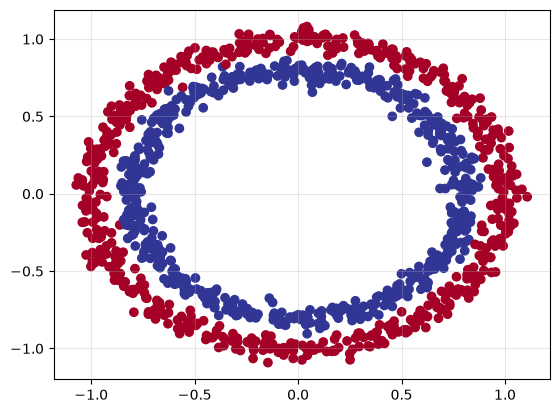

In [12]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);
plt.grid(True,alpha=0.3)

### Checking the input and output shapes.

In [8]:
x_sample=X[0]
y_sample=y[0]
print(f"X sample :{x_sample} and Y  sample:{y_sample}")
print(f"Shape of X sample :{x_sample.shape} and Shape of  Y sample {y_sample.shape}")

X sample :tensor([ 0.7729, -0.1616]) and Y  sample:1.0
Shape of X sample :torch.Size([2]) and Shape of  Y sample torch.Size([])


### Turn   data into tensors

In [13]:
import torch
print("done")

done


In [15]:
import torch
X = torch.as_tensor(X, dtype=torch.float32)
y = torch.as_tensor(y, dtype=torch.float32)

X[:5], y[:5]

(tensor([[ 0.7729, -0.1616],
         [-0.7135,  0.2336],
         [ 0.4764,  0.8684],
         [-0.0955, -1.0243],
         [ 0.8176,  0.5719]]),
 tensor([1., 1., 0., 0., 0.]))

### Train test split

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
X_train.shape

torch.Size([960, 2])

### **Step 2: Build a Model .**

###  Check the device

In [17]:
from torch import nn
device="cuda" if torch.cuda.is_available() else "Cpu"
print(f"Device : {device}")

Device : Cpu


### Creating the model

In [18]:
class Circlemodelv0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1=nn.Linear(
            in_features=2,
            out_features=5
        )
        self.layer2=nn.Linear(
            in_features=5,
            out_features=1
        )
    def forward(self,X):
        return self.layer2(self.layer1(X))
print("Done")

Done


### Create the model

In [19]:
model_0=Circlemodelv0()
print("Done")

Done


### Inspect the model

In [20]:
model_0

Circlemodelv0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

### Making the predictions before the training

In [21]:
untrained_preds=model_0(X_test)
print(f"Length of  predictions :{len(untrained_preds)} and shape:{untrained_preds.shape}")
print(f"Length of test samples :{len(y_test)} and sahpe {y_test.shape}")

Length of  predictions :240 and shape:torch.Size([240, 1])
Length of test samples :240 and sahpe torch.Size([240])


### Creating the Loss function

In [22]:
loss_fn=nn.BCEWithLogitsLoss()
print("done")

done


### Creating the Optimiser

In [23]:
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)
print("Done")

Done


### Creating the accuracy Function

In [24]:
def accuracy_f(y_true,y_pred):
    correct=torch.eq(y_true,y_pred).sum().item()
    acc=(correct/len(y_pred)*100)
    return acc
print("Done")

Done


#### **Step 3 Train the model :**

#### Convert logits into predition labels

In [25]:
y_logits=model_0(X_test)[:5]
y_logits

tensor([[0.5684],
        [0.7186],
        [0.5635],
        [0.4250],
        [0.5273]], grad_fn=<SliceBackward0>)

#### Apply sigmoid

In [26]:
y_pred_prob=torch.sigmoid(y_logits)
y_pred_prob

tensor([[0.6384],
        [0.6723],
        [0.6373],
        [0.6047],
        [0.6289]], grad_fn=<SigmoidBackward0>)

#### Convert probabiliteis into labels

In [27]:
y_preds=torch.round(y_pred_prob)
y_preds

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], grad_fn=<RoundBackward0>)

#### Build the Training and testing loop